## 1. What this notebook computes

The Revision record checked its program GKD (the generalized Kronecker delta of
notebook 01c) twice: a Rust self-test compared GKD with the author's determinant
on millions of pairs of index lists, and a Wolfram check received the values of
GKD for 346,304 pairs of index lists from a small Rust *exporter* program and
compared them with the author's own definition. Many of these lists were drawn
by a *pseudo-random* generator. Because such a generator is a fixed formula, the
lists can be made again, exactly. This notebook

- explains whole numbers in binary, how a byte stores $-1$, and the three bit
  operations (shift, exclusive or, keeping 64 bits) of the generator
  `xorshift64*` that the Revision programs use;
- writes that generator in Python and shows step by step what it does to the
  bits, and that its output looks random;
- regenerates, in Python, all 3,161,984 bytes that the Rust exporter wrote for
  the Wolfram check, and confirms the size and the sha256 fingerprint recorded in
  the Wolfram report, and every count of that report;
- repeats the Rust self-test for the lengths 5 to 9 (200,000 pairs each) and gets
  exactly the recorded numbers of nonzero values, comparing every value with the
  determinant;
- explains these numbers with the probability that labels drawn at random are
  all different, the "birthday problem".

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 01d (Reproducing the GKD self-tests of the Revision record bit for bit) is the
file `Revision/textbook/notebooks/01d_gkd_record_selftests.ipynb` of the repository
Dirac_claude. It explains whole numbers in binary, the storage of negative numbers in a
byte and the bit operations of the pseudo-random generator xorshift64star used by the
Revision programs, re-implements that generator in Python, regenerates the 3,161,984
bytes of generalized Kronecker delta values that the Rust program GKD gave the Wolfram
check of the Revision record and confirms their sha256 fingerprint and every count of
that record, repeats the Rust self-test of GKD with 200,000 pseudo-random pairs of index
lists for each length 5 to 9 and obtains exactly the recorded numbers of nonzero values,
compares every value with the determinant of the author's definition, and explains these
numbers with the probability that labels drawn at random are all different (the birthday
problem). It needs a computer with Windows 11, macOS or Linux, an internet connection for
the installation, the program Git, and Python 3.12 or newer (the notebooks were built
with Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy
1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient
0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, mpmath
and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 01d_gkd_record_selftests.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 30 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 01d_gkd_record_selftests.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
01d_gkd_record_selftests.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/01d.captions.json`
- `Revision/textbook/figures/01d_1_binary_counting.png`
- `Revision/textbook/figures/01d_2_generator_step.png`
- `Revision/textbook/figures/01d_3_generator_bits.png`
- `Revision/textbook/figures/01d_4_label_histogram.png`
- `Revision/textbook/figures/01d_5_record_counts.png`
- `Revision/textbook/figures/01d_6_birthday_problem.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all 6 figure files of this notebook exist
    ALL 19 CHECKS PASSED (notebook 01d)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/01d_gkd_record_selftests.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for a file below Revision/gkd_lovelock: the notebook reads reports
  of the Revision record; your copy of the repository is incomplete. Download it again
  with git clone and open the notebook inside the new copy.
- "AssertionError: check failed: the regenerated values have the size and the sha256
  fingerprint of the record": the file wolfram-gkd-report.json of your copy differs from
  the one the book was built with, or a cell above was changed; download the repository
  again and run all cells from the top without changing them.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 01d (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 01d (Reproducing the GKD self-tests of the Revision record bit for bit) is the
# file Revision/textbook/notebooks/01d_gkd_record_selftests.ipynb of the repository
# Dirac_claude. It explains whole numbers in binary, the storage of negative numbers in a
# byte and the bit operations of the pseudo-random generator xorshift64star used by the
# Revision programs, re-implements that generator in Python, regenerates the 3,161,984
# bytes of generalized Kronecker delta values that the Rust program GKD gave the Wolfram
# check of the Revision record and confirms their sha256 fingerprint and every count of
# that record, repeats the Rust self-test of GKD with 200,000 pseudo-random pairs of
# index lists for each length 5 to 9 and obtains exactly the recorded numbers of nonzero
# values, compares every value with the determinant of the author's definition, and
# explains these numbers with the probability that labels drawn at random are all
# different (the birthday problem). It needs a computer with Windows 11, macOS or Linux,
# an internet connection for the installation, the program Git, and Python 3.12 or newer
# (the notebooks were built with Python 3.14.5) with these packages at exactly these
# versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy, mpmath and matplotlib; the other packages run Jupyter,
# the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 01d_gkd_record_selftests.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 30
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 01d_gkd_record_selftests.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 01d_gkd_record_selftests.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/01d.captions.json
# - Revision/textbook/figures/01d_1_binary_counting.png
# - Revision/textbook/figures/01d_2_generator_step.png
# - Revision/textbook/figures/01d_3_generator_bits.png
# - Revision/textbook/figures/01d_4_label_histogram.png
# - Revision/textbook/figures/01d_5_record_counts.png
# - Revision/textbook/figures/01d_6_birthday_problem.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all 6 figure files of this notebook exist
#     ALL 19 CHECKS PASSED (notebook 01d)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/01d_gkd_record_selftests.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for a file below Revision/gkd_lovelock: the notebook reads
#   reports of the Revision record; your copy of the repository is incomplete. Download
#   it again with git clone and open the notebook inside the new copy.
# - "AssertionError: check failed: the regenerated values have the size and the sha256
#   fingerprint of the record": the file wolfram-gkd-report.json of your copy differs
#   from the one the book was built with, or a cell above was changed; download the
#   repository again and run all cells from the top without changing them.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "01d"  # this notebook: chapter 01, example d


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 01d complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Binary**: writing a whole number with the two digits 0 and 1; each digit
  (a **bit**) counts a power of 2: $2026 = 1024 + 512 + 256 + 128 + 64 + 32 + 8 +
  2$ is `11111101010` in binary.
- **Byte**: 8 bits, a whole number from 0 to 255. A **signed byte** uses the same
  8 bits for the numbers $-128$ to $127$: a negative number $-m$ is stored as
  $256 - m$ (the **two's complement**), so $-1$ is stored as 255, `11111111`.
- **Hexadecimal**: writing a number with the 16 digits `0`-`9` and `A`-`F`
  (worth 10 to 15); Python writes such a number with the prefix `0x`. One
  hexadecimal digit is exactly 4 bits.
- **Shift**: `x >> k` drops the last $k$ bits (the same as dividing by $2^k$ and
  dropping the remainder); `x << k` appends $k$ zero bits (multiplying by $2^k$).
- **Exclusive or** (`x ^ y`, XOR): compares the two numbers bit by bit; a result
  bit is 1 when exactly one of the two bits is 1.
- **Keeping 64 bits** (`x & MASK` with `MASK` $= 2^{64} - 1$): the remainder of $x$
  divided by $2^{64}$; the Rust programs compute with 64-bit numbers, so every
  result is cut to 64 bits.
- **Pseudo-random generator**: a formula that turns a number (its **state**) into
  a new state and an output, again and again; the outputs look random but are
  completely fixed by the first state, the **seed**.
- `xorshift64*`: the generator of the Revision programs: three shift-and-XOR
  steps on a 64-bit state and a multiplication of the output by a fixed odd
  number.
- **Fisher-Yates shuffle**: a way to put a list into a random order by swapping
  entries one after the other.
- **sha256 fingerprint**: a 64-digit hexadecimal number computed from a file by
  the method SHA-256; two different files have different fingerprints for all
  practical purposes, so equal fingerprints mean equal files, byte for byte.
- **Exporter**: the small Rust program, held as text inside the Wolfram check
  Revision/gkd_lovelock/verification/verify_lovelock_gkd.wls, that wrote the GKD
  values into a file for the Wolfram check.
- **Expected value, standard deviation**: for $N$ tries that each succeed with
  probability $q$, the number of successes is about $Nq$ (the expected value),
  typically within $\sqrt{Nq(1-q)}$ (one standard deviation) of it.

## 4. The physical and mathematical situation

The generalized Kronecker delta of two index lists of the same length $p$ over
the eight coordinates $x_1, \dots, x_8$ (labels $0, \dots, 7$ for the computer)
is the determinant of the matrix $M_{ij} = \delta(l_i, u_j)$; the program GKD
computes it as 0 for a repeated or missing label and otherwise as the sign of the
permutation that turns the upper list into the lower one (notebook 01c proves
this). It is the weight of every term of the Lovelock tensors of the author's
theory, so the record tested it hard:

1. the **Rust self-test** (`lovelock_gkd gkd-selftest`, file gkd-selftest.json)
   compared GKD with the literal Leibniz determinant for all pairs of lengths 1
   to 4 and for 200,000 pseudo-random pairs of each length 5 to 9;
2. the **Wolfram check** (wolfram-gkd-report.json) had the exporter write, as
   bytes, every pair of lengths 1, 2, 3 and 20,000 pseudo-random pairs of each
   length 4 to 7 with their GKD values, and called the author's own definition
   in Mathematica on every pair.

Both used the generator `xorshift64*` with stated seeds. This notebook rebuilds
the lists from the seeds and the recorded source code, so it can compare its
results with the record exactly: the same bytes, the same counts. A pseudo-random
sample is not a proof; the proof that GKD equals the determinant is the
four-case argument of notebook 01c. What this notebook shows is that the record's
numbers are exactly reproducible.

## 5. Whole numbers in binary

The next cell writes 2026 in binary with `format(number, "b")`, adds up the
binary digits times their powers of 2 to get the number back (the last digit
counts $2^0 = 1$, the one before $2^1 = 2$, and so on), prints the largest number
that 64 bits can hold, and shows how a signed byte stores $-1$: as 255, eight
ones. Python's `& 0xFF` keeps the last 8 bits of a number (0xFF is 255);
`int.from_bytes(..., signed=True)` reads a byte back as a signed number.

In [2]:
import hashlib  # the sha256 fingerprint
import itertools  # all index lists of a given length
import json  # reads the JSON reports of the record
import math  # factorials and falling factorials

import mpmath  # numbers with many digits
import numpy as np  # arrays

number = 2026
bits = format(number, "b")  # the binary digits, a text of 0s and 1s
say(f"{number} in binary: {bits} ({len(bits)} binary digits)")
# The last digit counts 2^0, the one before 2^1, ...: reversed() starts at the end.
by_places = sum(int(digit) * 2 ** place for place, digit in enumerate(reversed(bits)))
check(by_places == number == int(bits, 2), "the binary digits of 2026 give back 2026")
say(f"the largest number that 64 bits can hold: 2^64 - 1 = {2 ** 64 - 1}")
stored = (-1) & 0xFF  # the 8 bits that a signed byte uses for -1
read_back = int.from_bytes(bytes([stored]), "big", signed=True)
stored_bits = format(stored, "08b")  # 8 binary digits, zeros in front
say(f"-1 in a signed byte: {stored} = {stored_bits}, read back as {read_back}")
check(stored == 255 and read_back == -1, "a signed byte stores -1 as 255 = 11111111")

2026 in binary: 11111101010 (11 binary digits)
PASS the binary digits of 2026 give back 2026
the largest number that 64 bits can hold: 2^64 - 1 = 18446744073709551615
-1 in a signed byte: 255 = 11111111, read back as -1
PASS a signed byte stores -1 as 255 = 11111111


The next cell draws the numbers 0 to 31 in binary: one column per number, one
row per bit, from $2^4 = 16$ at the top to $2^0 = 1$ at the bottom (dark is 1).
The bottom row alternates with every number, the next row every two numbers, the
next every four: binary counting.

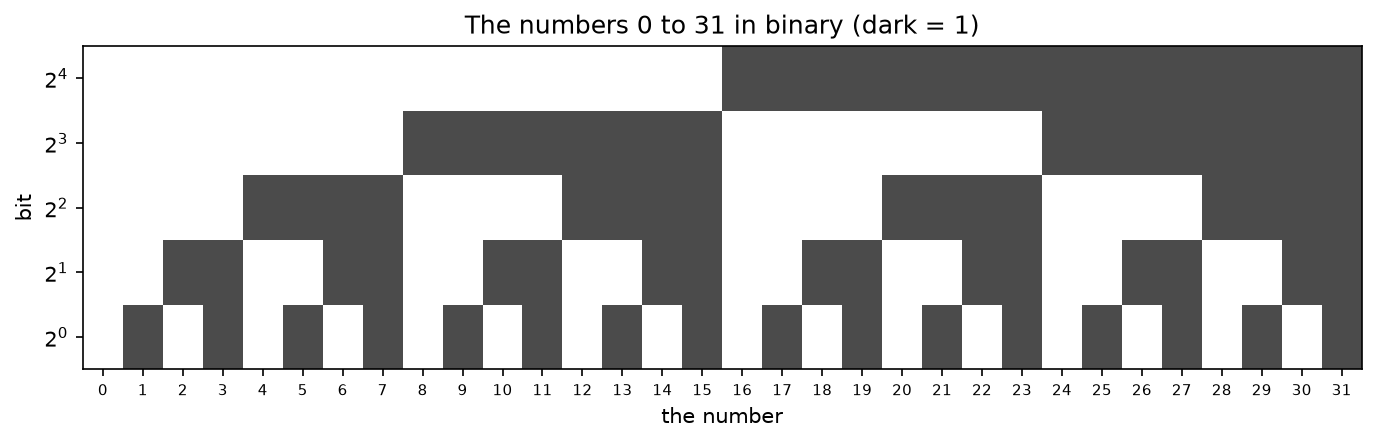

Figure 01d.1 saved as Revision/textbook/figures/01d_1_binary_counting.png


In [3]:
numbers = np.arange(32)
bit_rows = np.array([(numbers >> k) & 1 for k in range(4, -1, -1)])  # 2^4 ... 2^0
fig, ax = plt.subplots(figsize=(11.0, 2.8))
ax.imshow(bit_rows, cmap="Greys", vmin=0, vmax=1.3, aspect="auto")
ax.grid(False)
ax.set_xticks(range(32), [str(k) for k in range(32)], fontsize=7)
ax.set_yticks(range(5), [f"$2^{k}$" for k in range(4, -1, -1)])
ax.set_xlabel("the number")
ax.set_ylabel("bit")
ax.set_title("The numbers 0 to 31 in binary (dark = 1)")
save_figure(fig, "binary_counting",
            "The numbers 0 to 31 (columns) written in binary: each row is one bit, "
            "counting $2^4 = 16$ (top) down to $2^0 = 1$ (bottom), dark for the "
            "digit 1 and white for 0. Adding the powers of 2 of the dark squares "
            "of a column gives its number; the lowest bit changes with every "
            "number, the next one every 2 numbers, the next every 4.")

## 6. The three bit operations

The next cell applies the operations of the generator to the 8-bit number
$x = 182$ = `10110110` and prints the bits of each result (`format(v, "08b")`
writes a number with at least 8 binary digits):

- `x >> 2` drops the last two bits: `101101` = 45, the same as $182 // 4$ (whole
  number division);
- `x << 3` appends three zero bits: $182 \cdot 8 = 1456$;
- `(x << 3) & 0xFF` keeps the last 8 bits: the remainder of 1456 divided by 256;
- `x ^ 0b11110000` flips the first four of the eight bits.

It checks these rules on 1000 random 64-bit numbers too, and that applying the
same exclusive or twice gives back the number, which is why an XOR step loses
nothing.

In [4]:
def binary(value, width=8):
    """value in binary with at least width digits (zeros in front)."""
    return format(value, "b").zfill(width)


x = 182
say(f"x                 = {binary(x)} = {x}")
say(f"x >> 2            = {binary(x >> 2)} = {x >> 2} = {x} // 4")
say(f"x << 3            = {binary(x << 3, 11)} = {x << 3} = {x} * 8")
say(f"(x << 3) & 0xFF   = {binary((x << 3) & 0xFF)} = {(x << 3) & 0xFF} "
    f"= {x << 3} % 256")
say(f"x ^ 0b11110000    = {binary(x ^ 0b11110000)} = {x ^ 0b11110000}")
MASK = 2 ** 64 - 1  # 64 ones: "& MASK" keeps the last 64 bits
generator = np.random.default_rng(12345)
rules_hold = True
for _ in range(1000):
    a = int(generator.integers(0, 2 ** 63)) * 2 + int(generator.integers(0, 2))
    b = int(generator.integers(0, 2 ** 63)) * 2 + int(generator.integers(0, 2))
    k = int(generator.integers(1, 64))
    rules_hold &= (a >> k) == a // 2 ** k
    rules_hold &= ((a << k) & MASK) == (a * 2 ** k) % 2 ** 64
    rules_hold &= ((a ^ b) ^ b) == a
check(rules_hold, "shift = division or multiplication by 2^k, & MASK = remainder "
      "modulo 2^64, and XOR twice gives back the number (1000 random 64-bit numbers)")

x                 = 10110110 = 182
x >> 2            = 00101101 = 45 = 182 // 4
x << 3            = 10110110000 = 1456 = 182 * 8
(x << 3) & 0xFF   = 10110000 = 176 = 1456 % 256
x ^ 0b11110000    = 01000110 = 70
PASS shift = division or multiplication by 2^k, & MASK = remainder modulo 2^64, and XOR
    twice gives back the number (1000 random 64-bit numbers)


## 7. The generator `xorshift64*`, step by step

One step of the generator, as written in the record's Rust code (the function
`compare_random` of Revision/gkd_lovelock/code/src/gkd.rs and the exporter in
verify_lovelock_gkd.wls):

1. `x ^= x >> 12`: XOR the state with itself shifted 12 bits to the right;
2. `x ^= x << 25`: XOR with itself shifted 25 bits to the left (Rust keeps 64
   bits, so we write `& MASK`);
3. `x ^= x >> 27`: XOR with itself shifted 27 bits to the right; this is the new
   state;
4. the output is the new state times the odd constant `0x2545F4914F6CDD1D`, cut
   to 64 bits.

The generator's output `below(n)`, a label from 0 to $n - 1$, is the output's
remainder after division by $n$. The exporter starts from the seed
`0x243F6A8885A308D3 XOR p` for the length $p$; these 16 hexadecimal digits are
the first digits of $\pi$ after the point, written in base 16 (a number that
nobody chose to make a test pass). The Rust self-test starts from
`(0x2545F4914F6CDD1D XOR p) OR 1` (`| 1` makes the last bit 1).

The next cell writes the generator as a small Python class, checks the digits of
$\pi$ with mpmath, and checks that the same seed always gives the same numbers
while a different seed gives different ones.

In [5]:
MULTIPLIER = 0x2545F4914F6CDD1D  # the constant of xorshift64*
EXPORTER_SEED = 0x243F6A8885A308D3  # the first 16 hexadecimal digits of pi
SELFTEST_SEED = 0x2545F4914F6CDD1D  # the Rust self-test uses the same constant


class XorShift64Star:
    """The pseudo-random generator of the Revision programs."""

    def __init__(self, seed):
        self.state = seed

    def below(self, n):
        """One step of the generator; returns its output modulo n (0 ... n-1)."""
        x = self.state
        x ^= x >> 12
        x ^= (x << 25) & MASK
        x ^= x >> 27
        self.state = x
        return ((x * MULTIPLIER) & MASK) % n


say(f"MULTIPLIER = {MULTIPLIER} (decimal), EXPORTER_SEED = {EXPORTER_SEED} (decimal)")
mpmath.mp.dps = 40  # 40 significant digits are plenty for 16 hexadecimal digits
# frac(pi) = 0.14159...; times 16^16 shifts 16 hexadecimal digits before the point
pi_hex = int(mpmath.floor(mpmath.frac(mpmath.pi) * 16 ** 16))
say(f"the first 16 hexadecimal digits of pi after the point: {pi_hex:016X}")
check(pi_hex == EXPORTER_SEED, "the exporter's seed is made of the hexadecimal "
      "digits of pi")
first = XorShift64Star(EXPORTER_SEED ^ 4)
again = XorShift64Star(EXPORTER_SEED ^ 4)
other = XorShift64Star(EXPORTER_SEED ^ 5)
numbers_first = [first.below(2 ** 64) for _ in range(1000)]
check(numbers_first == [again.below(2 ** 64) for _ in range(1000)] and
      numbers_first != [other.below(2 ** 64) for _ in range(1000)],
      "the same seed gives the same 1000 outputs, another seed other outputs")

MULTIPLIER = 2685821657736338717 (decimal), EXPORTER_SEED = 2611923443488327891 (decimal)
the first 16 hexadecimal digits of pi after the point: 243F6A8885A308D3
PASS the exporter's seed is made of the hexadecimal digits of pi
PASS the same seed gives the same 1000 outputs, another seed other outputs


The next cell follows the bits through one step, starting from the exporter's
seed for length 4, and draws them as five rows of 64 squares (dark = 1, the
highest bit on the left): the state, the state after each of the three XOR
steps, and the output.

PASS the class gives the output computed step by step


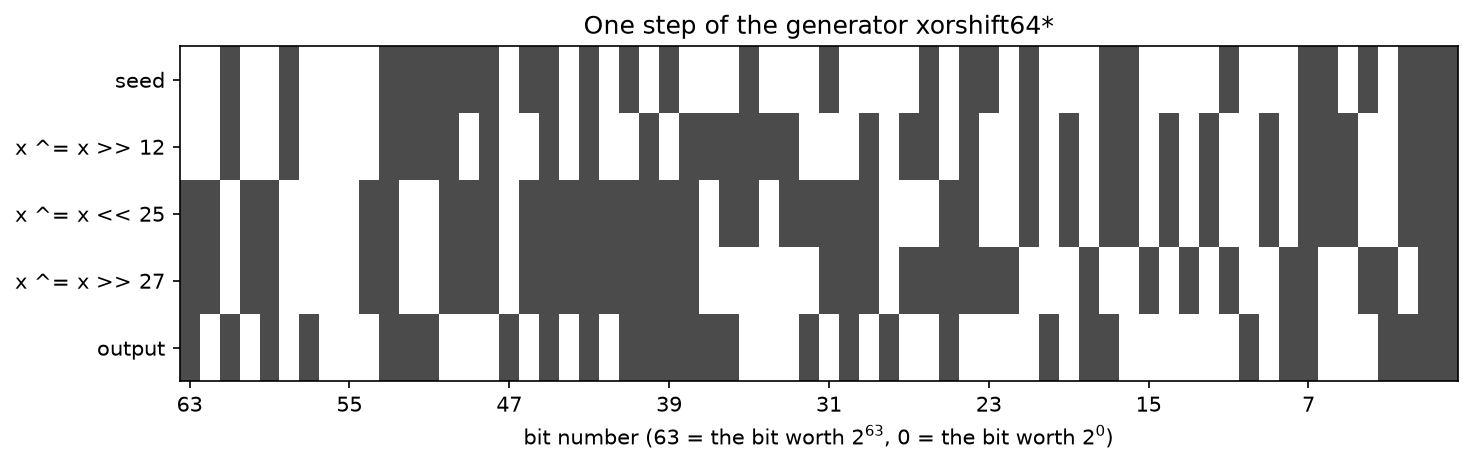

Figure 01d.2 saved as Revision/textbook/figures/01d_2_generator_step.png


In [6]:
def bit_row(value):
    """The 64 bits of value, highest first, as a list of 0s and 1s."""
    return [(value >> k) & 1 for k in range(63, -1, -1)]


state = EXPORTER_SEED ^ 4
after_1 = state ^ (state >> 12)
after_2 = after_1 ^ ((after_1 << 25) & MASK)
after_3 = after_2 ^ (after_2 >> 27)  # the new state
output = (after_3 * MULTIPLIER) & MASK
check(XorShift64Star(state).below(2 ** 64) == output,
      "the class gives the output computed step by step")
fig, ax = plt.subplots(figsize=(11.0, 2.9))
ax.imshow([bit_row(v) for v in (state, after_1, after_2, after_3, output)],
          cmap="Greys", vmin=0, vmax=1.3, aspect="auto")
ax.grid(False)
ax.set_yticks(range(5), ["seed", "x ^= x >> 12", "x ^= x << 25", "x ^= x >> 27",
                         "output"])
ax.set_xticks(range(0, 64, 8), [str(63 - k) for k in range(0, 64, 8)])
ax.set_xlabel("bit number (63 = the bit worth $2^{63}$, 0 = the bit worth $2^0$)")
ax.set_title("One step of the generator xorshift64*")
save_figure(fig, "generator_step",
            "The 64 bits (dark = 1) of the exporter's seed for length 4 (top row) "
            "and of the number after each of the three shift-and-exclusive-or "
            "steps of the generator; the fourth row is the new state and the "
            "bottom row the output (new state times the constant "
            "0x2545F4914F6CDD1D, cut to 64 bits). Horizontal axis the bit "
            "number from 63 (worth $2^{63}$, left) to 0 (worth 1, right). Each "
            "step mixes the bits further.")

## 8. Do the numbers look random?

The next cell draws the 64 bits of the first 64 outputs of the same generator
(one row per output) and then counts how often each label 0 to 7 comes out among
the first 160,000 calls of `below(8)`. Each label should come out about
160,000/8 = 20,000 times, with a standard deviation of
$\sqrt{160000 \cdot \tfrac18 \cdot \tfrac78} \approx 132$. The check asks that
every count lies within 5 standard deviations of 20,000. A single count of a fair
source lies further away with a probability of about 0.6 in a million, so with
8 counts a fair source fails this check with a probability of about 5 in a
million.

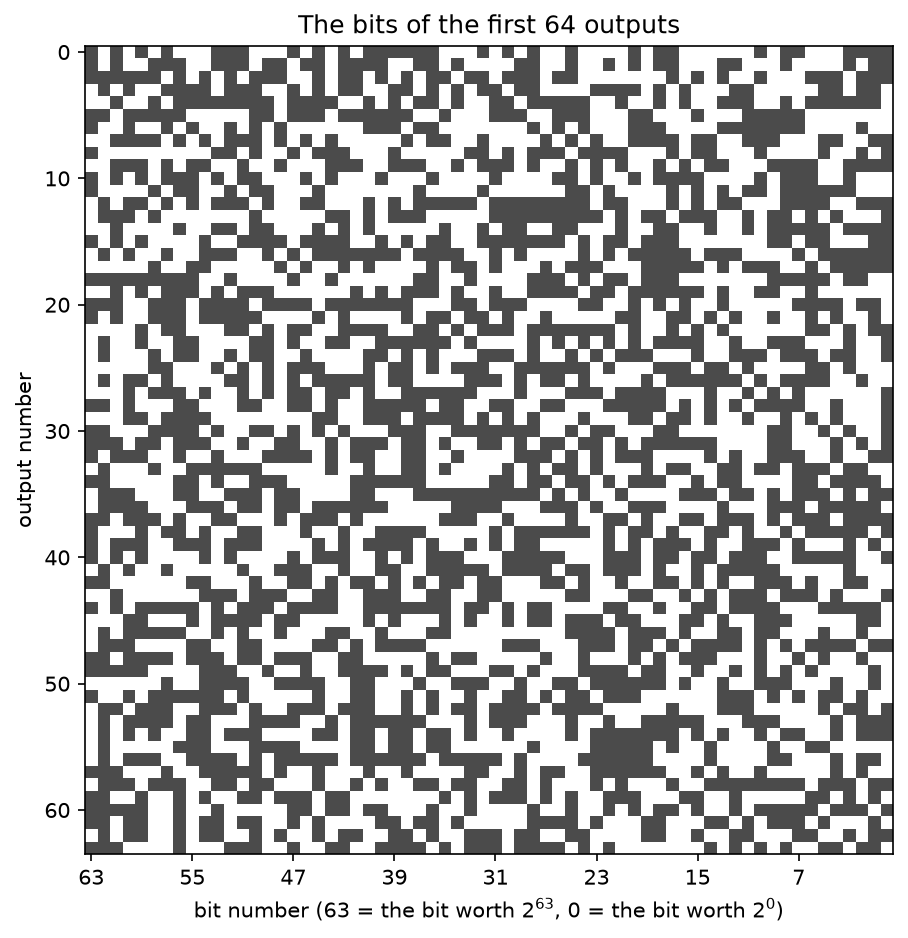

Figure 01d.3 saved as Revision/textbook/figures/01d_3_generator_bits.png
counts of the labels 0 ... 7: [20002, 20179, 20098, 19871, 20045, 19959, 20036, 19810]
largest distance from 20000: 190, standard deviation 132.3
PASS every label comes out within 5 standard deviations of 20000 times


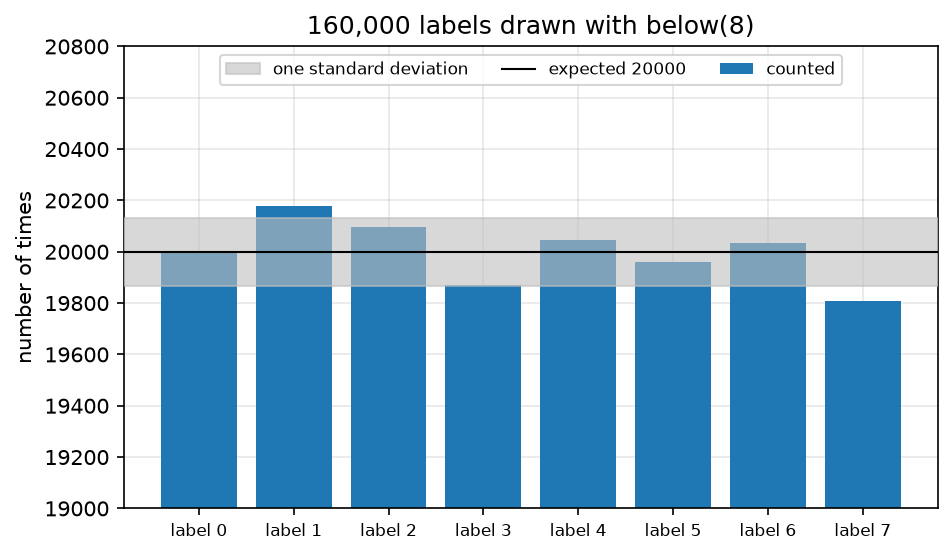

Figure 01d.4 saved as Revision/textbook/figures/01d_4_label_histogram.png


In [7]:
stream = XorShift64Star(EXPORTER_SEED ^ 4)
outputs = [stream.below(2 ** 64) for _ in range(64)]
fig, ax = plt.subplots(figsize=(7.2, 7.0))
ax.imshow([bit_row(v) for v in outputs], cmap="Greys", vmin=0, vmax=1.3)
ax.grid(False)
# column 0 holds the bit worth 2^63, column 63 the bit worth 2^0: label by bit number
ax.set_xticks(range(0, 64, 8), [str(63 - k) for k in range(0, 64, 8)])
ax.set_xlabel("bit number (63 = the bit worth $2^{63}$, 0 = the bit worth $2^0$)")
ax.set_ylabel("output number")
ax.set_title("The bits of the first 64 outputs")
save_figure(fig, "generator_bits",
            "The 64 bits (columns, dark = 1, the highest bit on the left) of the "
            "first 64 outputs (rows, the first at the top) of the generator "
            "of the record started from the exporter's seed for length 4. No row, "
            "column or diagonal pattern is visible: the bits look random, "
            "although every one of them is fixed by the seed.")
stream = XorShift64Star(EXPORTER_SEED ^ 4)
labels_drawn = np.array([stream.below(8) for _ in range(160000)])
label_counts = np.bincount(labels_drawn, minlength=8)  # how often 0, 1, ..., 7
spread = math.sqrt(160000 * (1 / 8) * (7 / 8))  # the standard deviation
say(f"counts of the labels 0 ... 7: {label_counts.tolist()}")
say(f"largest distance from 20000: {int(np.max(np.abs(label_counts - 20000)))}, "
    f"standard deviation {spread:.1f}")
check(bool(np.all(np.abs(label_counts - 20000) < 5 * spread)),
      "every label comes out within 5 standard deviations of 20000 times")
fig, ax = plt.subplots(figsize=(7.0, 4.0))
ax.axhspan(20000 - spread, 20000 + spread, color="0.75", alpha=0.6, zorder=3,
           label="one standard deviation")  # drawn over the bars, see-through
ax.bar(range(8), label_counts, color="tab:blue", zorder=2, label="counted")
ax.axhline(20000, color="black", lw=1, zorder=4, label="expected 20000")
ax.set_ylim(19000, 20800)
ax.set_xticks(range(8), [f"label {k}" for k in range(8)], fontsize=8)
ax.set_ylabel("number of times")
ax.set_title("160,000 labels drawn with below(8)")
ax.legend(loc="upper center", ncol=3, fontsize=8);  # above the bars, not on them
save_figure(fig, "label_histogram",
            "How often each label 0 to 7 came out in 160,000 calls of below(8) of "
            "the generator (blue bars), the expected number 20,000 (black line) "
            "and the band of one standard deviation, about 132, around it (grey); "
            "horizontal axis the label, vertical axis the number of times (the "
            "axis starts at 19,000 to make the small differences visible). The "
            "counts scatter around 20,000 as a fair random source would.")

## 9. The GKD values that the Rust exporter gave the Wolfram check

The exporter, whose Rust source is printed inside the Wolfram check
verify_lovelock_gkd.wls, writes one **record** of signed bytes per pair of index
lists: the length $p$, the $p$ lower labels, the $p$ upper labels, and the GKD
value ($+1$, 0, or $-1$ stored as 255). It writes

- for $p = 1, 2, 3$ every pair, in the order of Mathematica's
  `Tuples[Range[0, 7], 2 p]` (all lists of $2p$ labels in dictionary order; the
  first $p$ are the lower list, the last $p$ the upper list), which is the order
  of Python's `itertools.product(range(8), repeat=2 * p)`;
- for $p = 4, 5, 6, 7$ 20,000 pairs from the generator with the seed
  `0x243F6A8885A308D3 XOR p`: an even sample (number 0, 2, 4, ...) takes $p$
  different labels (for $i = 0, \dots, p - 1$ it swaps place $i$ of the list
  $0, \dots, 7$ with place $i$ + `below(8 - i)`) as the upper list, and a
  re-ordering of them (for $i = p - 1$ down to 1 it swaps place $i$ with place
  `below(i + 1)`) as the lower list; an odd sample draws $p$ upper labels and
  then $p$ lower labels with `below(8)`.

The next cell defines the GKD rule (as in notebook 01c), regenerates all records
in this order, and keeps the lists and values for the next sections. Then it
compares the size of the bytes and their sha256 fingerprint with the record's
`gkdValuesSource`. Equal fingerprints mean that every one of the 3,161,984 bytes
is the same: the same pairs, in the same order, with the same GKD values. To show
how sensitive the fingerprint is, it also prints the fingerprint after changing
a single byte.

In [8]:
def inversions(order):
    """The number of pairs of places i < j whose entries stand in the wrong order."""
    return sum(1 for i in range(len(order)) for j in range(i + 1, len(order))
               if order[i] > order[j])


def gkd_rule(lower, upper):
    """The program GKD (Revision/gkd_lovelock/code/src/gkd.rs) in Python."""
    place = {}
    for j, u_label in enumerate(upper):
        if u_label in place:  # a repeated upper label: two equal columns
            return 0
        place[u_label] = j
    sigma = []
    for l_label in lower:
        if l_label not in place or place[l_label] in sigma:  # missing or repeated
            return 0
        sigma.append(place[l_label])
    return 1 if inversions(sigma) % 2 == 0 else -1  # the sign of the permutation


values_bytes = bytearray()  # the regenerated file, byte by byte
pairs_of = {p: ([], []) for p in range(1, 8)}  # p -> (lower lists, upper lists)
for p in (1, 2, 3):  # every pair, in the order of Tuples[Range[0, 7], 2 p]
    for digits in itertools.product(range(8), repeat=2 * p):
        pairs_of[p][0].append(list(digits[:p]))
        pairs_of[p][1].append(list(digits[p:]))
for p in (4, 5, 6, 7):  # 20000 pseudo-random pairs each
    rng = XorShift64Star(EXPORTER_SEED ^ p)
    for sample in range(20000):
        if sample % 2 == 0:  # p different labels and a re-ordering of them
            labels = list(range(8))
            for i in range(p):
                j = i + rng.below(8 - i)
                labels[i], labels[j] = labels[j], labels[i]
            upper = labels[:p]
            lower = list(upper)
            for i in range(p - 1, 0, -1):
                j = rng.below(i + 1)
                lower[i], lower[j] = lower[j], lower[i]
        else:  # two arbitrary lists, the upper one drawn first
            upper = [rng.below(8) for _ in range(p)]
            lower = [rng.below(8) for _ in range(p)]
        pairs_of[p][0].append(lower)
        pairs_of[p][1].append(upper)
gkd_values = {}  # p -> array of the GKD values, in the order of the file
for p in range(1, 8):
    values_p = []
    for lower, upper in zip(*pairs_of[p]):
        value = gkd_rule(lower, upper)
        values_p.append(value)
        values_bytes.append(p)
        values_bytes.extend(lower)
        values_bytes.extend(upper)
        values_bytes.append(value & 0xFF)  # -1 is stored as 255
    gkd_values[p] = np.array(values_p)
wolfram_path = repository_file("Revision/gkd_lovelock/results/wolfram-gkd-report.json")
wolfram = json.loads(wolfram_path.read_text(encoding="utf-8"))
source = wolfram["gkdValuesSource"]
fingerprint = hashlib.sha256(bytes(values_bytes)).hexdigest()
record_bytes, record_sha256 = source["valuesFileBytes"], source["valuesFileSha256"]
say(f"bytes regenerated {len(values_bytes)}, in the record {record_bytes}")
say(f"sha256 regenerated:   {fingerprint}")
report("regenerated GKD values (bytes)", len(values_bytes))
report("their sha256, first 16 digits", fingerprint[:16])
say(f"sha256 in the record: {record_sha256}")
check(len(values_bytes) == source["valuesFileBytes"] and
      fingerprint == source["valuesFileSha256"],
      "the regenerated values have the size and the sha256 fingerprint of the record",
      record="Revision/gkd_lovelock/results/wolfram-gkd-report.json, gkdValuesSource")
changed = bytearray(values_bytes)
changed[1000] ^= 1  # change one bit of one byte
say("after changing one bit of byte 1000:")
say(f"sha256 of the changed: {hashlib.sha256(bytes(changed)).hexdigest()}")
layout = [len(pairs_of[p][0]) for p in range(1, 8)]
wolfram_checks = {c["name"]: c for c in wolfram["checks"]}
check(layout == [64, 4096, 262144, 20000, 20000, 20000, 20000] and
      wolfram_checks["gkd_values_file_layout"]["verdict"] == "PASS",
      "the layout: 64, 4096, 262144 pairs of length 1, 2, 3 and 20000 of each "
      "length 4 to 7", record="Revision/gkd_lovelock/results/"
      "wolfram-gkd-report.json, check gkd_values_file_layout")

bytes regenerated 3161984, in the record 3161984
sha256 regenerated:   3ddccfa744b3708bbd3e251852236b0a2d3370e957c67bae8d94168de6d2d695
RESULT regenerated GKD values (bytes) = 3161984
RESULT their sha256, first 16 digits = 3ddccfa744b3708b
sha256 in the record: 3ddccfa744b3708bbd3e251852236b0a2d3370e957c67bae8d94168de6d2d695
PASS the regenerated values have the size and the sha256 fingerprint of the record
     reproduces Revision/gkd_lovelock/results/wolfram-gkd-report.json, gkdValuesSource
after changing one bit of byte 1000:
sha256 of the changed: 4463b17c1baf0a3e56278f2a4834d64cc1e8901e92a0a37c6036d8e93aa0445e
PASS the layout: 64, 4096, 262144 pairs of length 1, 2, 3 and 20000 of each length 4 to 7
     reproduces Revision/gkd_lovelock/results/wolfram-gkd-report.json, check
    gkd_values_file_layout


## 10. Their counts, compared with the record

For each length $p$ the Wolfram report records in `measurements.gkdComparison`:
the number of pairs, the number of mismatches between GKD and the author's
determinant, the numbers of values $+1$, $-1$ and 0, the number of mismatches
when the determinant is compared with $-$GKD instead (a *negative control*: a
test that must fail, to show that the comparison can fail; it fails exactly where
GKD is not zero), and for $p \geq 4$ the number of nonzero values among the
10,000 even samples (all of them, by construction).

The next cell computes the author's determinant for all 346,304 pairs, with the
Leibniz formula applied to many pairs at once as in notebook 01c (`literal_many`;
for $p = 7$ the formula has $7! = 5040$ terms), builds the same table and
compares it, entry by entry, with the record.

In [9]:
SIGNED = {}  # size n -> list of (permutation, sign)


def signed_permutations(n):
    if n not in SIGNED:
        SIGNED[n] = [(order, 1 if inversions(order) % 2 == 0 else -1)
                     for order in itertools.permutations(range(n))]
    return SIGNED[n]


def literal_many(lowers, uppers):
    """Det[Outer[delta, lower, upper]] for many pairs at once (Leibniz formula)."""
    p = lowers.shape[1]
    outer = lowers[:, :, None] == uppers[:, None, :]  # shape (pairs, p, p)
    values = np.zeros(len(lowers), dtype=np.int64)
    rows = np.arange(p)
    for order, order_sign in signed_permutations(p):
        values += order_sign * outer[:, rows, list(order)].all(axis=1)
    return values


measured = []
for p in range(1, 8):
    lowers = np.array(pairs_of[p][0], dtype=np.int8)
    uppers = np.array(pairs_of[p][1], dtype=np.int8)
    determinant = literal_many(lowers, uppers)
    values_p = gkd_values[p]
    row = {"p": p, "pairs": len(values_p),
           "mismatches": int((determinant != values_p).sum()),
           "plusOne": int((values_p == 1).sum()),
           "minusOne": int((values_p == -1).sum()),
           "zero": int((values_p == 0).sum()),
           "mismatchesAgainstMinusGKD": int((determinant != -values_p).sum())}
    if p >= 4:  # the even samples are the re-orderings
        row["permutationSamplesNonzero"] = int((values_p[0::2] != 0).sum())
    measured.append(row)
    # format(**row) fills the names in braces with the entries of the dictionary
    say("p = {p}: pairs {pairs:6d}, mismatches {mismatches}, +1 {plusOne:4d}, "
        "-1 {minusOne:4d}, 0 {zero:6d}, against -GKD "
        "{mismatchesAgainstMinusGKD:5d}".format(**row))
recorded = wolfram["measurements"]["gkdComparison"]
check(measured == recorded, "every number of the record's gkdComparison table is "
      "reproduced (lengths 1 to 7)",
      record="Revision/gkd_lovelock/results/wolfram-gkd-report.json, measurements "
             "gkdComparison; checks gkd_equals_kdelta_exhaustive_length_1 to 3 and "
             "gkd_equals_kdelta_random_length_4 to 7")
check(all(r["mismatches"] == 0 for r in measured),
      "the author's determinant equals GKD on all 346304 pairs")
check(all(r["mismatchesAgainstMinusGKD"] == r["plusOne"] + r["minusOne"] > 0
          for r in measured),
      "negative control: compared with -GKD, the test fails exactly at the "
      "nonzero values", record="Revision/gkd_lovelock/results/wolfram-gkd-report"
      ".json, check negative_control_gkd_comparison_detects_a_sign_flip")

p = 1: pairs     64, mismatches 0, +1    8, -1    0, 0     56, against -GKD     8
p = 2: pairs   4096, mismatches 0, +1   56, -1   56, 0   3984, against -GKD   112
p = 3: pairs 262144, mismatches 0, +1 1008, -1 1008, 0 260128, against -GKD  2016
p = 4: pairs  20000, mismatches 0, +1 4998, -1 5024, 0   9978, against -GKD 10022
p = 5: pairs  20000, mismatches 0, +1 5024, -1 4981, 0   9995, against -GKD 10005
p = 6: pairs  20000, mismatches 0, +1 4882, -1 5120, 0   9998, against -GKD 10002
p = 7: pairs  20000, mismatches 0, +1 4935, -1 5065, 0  10000, against -GKD 10000
PASS every number of the record's gkdComparison table is reproduced (lengths 1 to 7)
     reproduces Revision/gkd_lovelock/results/wolfram-gkd-report.json, measurements
    gkdComparison; checks gkd_equals_kdelta_exhaustive_length_1 to 3 and
    gkd_equals_kdelta_random_length_4 to 7
PASS the author's determinant equals GKD on all 346304 pairs
PASS negative control: compared with -GKD, the test fails exactly at the nonzero

The next cell draws the reproduced counts of $+1$, $-1$ and 0 for every length as
bars on a logarithmic scale and marks the record's numbers with black crosses on
top of them: every cross sits exactly on the top of its bar.

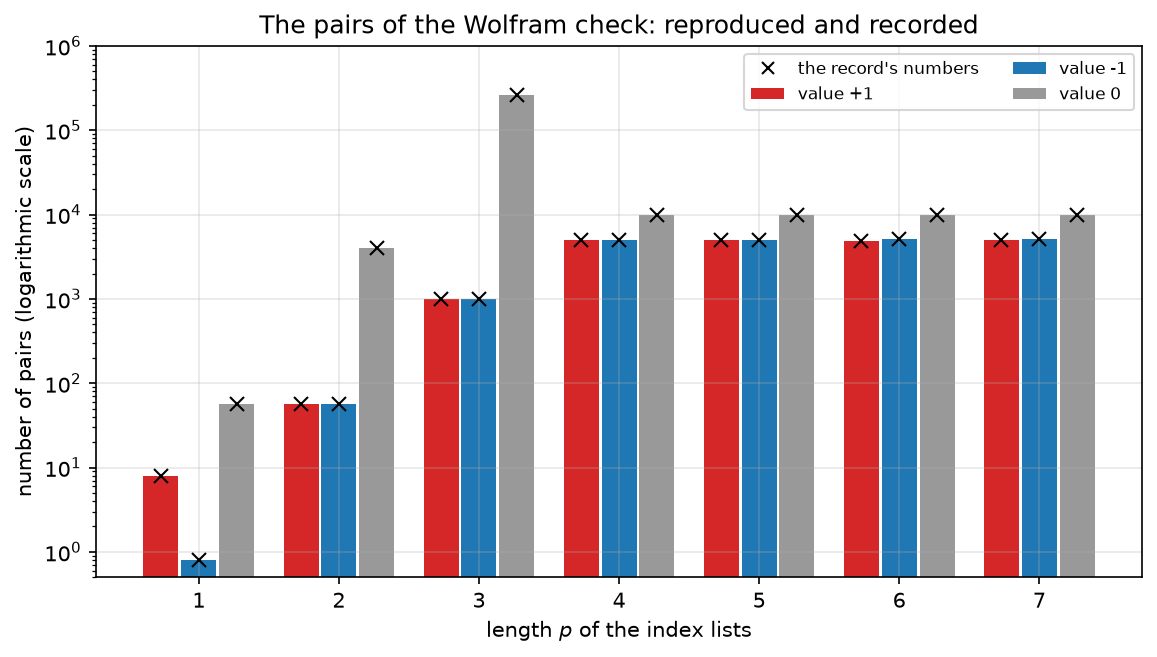

Figure 01d.5 saved as Revision/textbook/figures/01d_5_record_counts.png


In [10]:
fig, ax = plt.subplots(figsize=(9.0, 4.6))
lengths = np.arange(1, 8)
for shift, key, color, name in [(-0.27, "plusOne", "tab:red", "value +1"),
                                (0.0, "minusOne", "tab:blue", "value -1"),
                                (0.27, "zero", "0.6", "value 0")]:
    heights = [max(row[key], 0.8) for row in measured]  # 0.8 marks a count 0
    ax.bar(lengths + shift, heights, width=0.25, color=color, label=name)
    ax.plot(lengths + shift, [max(row[key], 0.8) for row in recorded], "kx", ms=7)
ax.plot([], [], "kx", label="the record's numbers")  # an entry for the legend only
ax.set_yscale("log")
ax.set_ylim(0.5, 1e6)
ax.set_xticks(lengths)
ax.set_xlabel("length $p$ of the index lists")
ax.set_ylabel("number of pairs (logarithmic scale)")
ax.set_title("The pairs of the Wolfram check: reproduced and recorded")
ax.legend(loc="upper right", ncol=2, fontsize=8);
save_figure(fig, "record_counts",
            "The number of pairs of index lists with the GKD value $+1$ (red), "
            "$-1$ (blue) and 0 (grey) among the pairs that the exporter wrote for "
            "the Wolfram check: all pairs of the lengths 1 to 3 and 20,000 "
            "pseudo-random pairs of each length 4 to 7, as regenerated by this "
            "notebook (bars), and the numbers stored in the record (black "
            "crosses); horizontal axis the length $p$, vertical axis the number of "
            "pairs on a logarithmic scale (a count 0 is drawn as a short stub). "
            "Every cross sits on its bar.")

## 11. The Rust self-test for the lengths 5 to 9

The function `compare_random(p, 8, 200000, seed)` of gkd.rs, called by the
self-test with the seed `0x2545F4914F6CDD1D XOR p`, starts the generator at
`seed OR 1` and draws 200,000 samples: for each one $p$ upper labels with
`below(8)`; for an even sample the lower list is the upper list re-ordered (for
$i = p - 1$ down to 1 swap place $i$ with place `below(i + 1)`), for an odd sample
$p$ more labels with `below(8)`. It counts the nonzero GKD values and the
mismatches with the Leibniz determinant; gkd-selftest.json records both.

The next cell repeats this. GKD is computed for all samples at once with the
sign shortcut of notebook 01c (`rule_many`: the sign of the re-ordering is the
product of the signs of the two lists), and the determinant with numpy's
elimination (`np.linalg.det`, floating point, then rounded; the Leibniz formula
would have $9!$ = 362,880 terms per matrix). The cell checks that every
determinant is a whole number up to $10^{-6}$. It takes 10 to 30 seconds.

In [11]:
def rule_many(lowers, uppers):
    """GKD for many pairs at once: 0, or sign(lower list) times sign(upper list)."""
    p = lowers.shape[1]
    upper_sorted = np.sort(uppers, axis=1)
    upper_distinct = (np.diff(upper_sorted, axis=1) != 0).all(axis=1)
    same_labels = (np.sort(lowers, axis=1) == upper_sorted).all(axis=1)
    first, second = np.triu_indices(p, 1)  # all pairs of places first < second
    parity = ((lowers[:, first] > lowers[:, second]).sum(axis=1)
              + (uppers[:, first] > uppers[:, second]).sum(axis=1)) % 2
    return np.where(upper_distinct & same_labels, np.where(parity == 0, 1, -1), 0)


check(all((rule_many(np.array(pairs_of[p][0], dtype=np.int8),
                     np.array(pairs_of[p][1], dtype=np.int8)) == gkd_values[p]).all()
          for p in range(1, 8)),
      "rule_many equals the plain GKD rule on all 346304 pairs of the exporter")
selftest = json.loads(repository_file("Revision/gkd_lovelock/results/"
                                      "gkd-selftest.json").read_text(encoding="utf-8"))
recorded_random = {e["p"]: e for e in selftest["results"] if e["mode"] == "random"}
selftest_rows = {}
whole_numbers = True
for p in (5, 6, 7, 8, 9):
    rng = XorShift64Star((SELFTEST_SEED ^ p) | 1)
    lowers, uppers = [], []
    for sample in range(200000):
        upper = [rng.below(8) for _ in range(p)]
        if sample % 2 == 0:  # a re-ordering of the upper list
            lower = list(upper)
            for i in range(p - 1, 0, -1):
                j = rng.below(i + 1)
                lower[i], lower[j] = lower[j], lower[i]
        else:  # an arbitrary lower list
            lower = [rng.below(8) for _ in range(p)]
        lowers.append(lower)
        uppers.append(upper)
    lowers = np.array(lowers, dtype=np.int8)
    uppers = np.array(uppers, dtype=np.int8)
    values_p = rule_many(lowers, uppers)
    determinants = np.concatenate([  # numpy's elimination, in 4 blocks of 50000
        np.linalg.det((lowers[s:s + 50000, :, None]
                       == uppers[s:s + 50000, None, :]).astype(float))
        for s in range(0, 200000, 50000)])
    rounded = np.rint(determinants)  # the nearest whole numbers
    whole_numbers &= bool(np.all(np.abs(determinants - rounded) < 1e-6))
    selftest_rows[p] = {"pairs": len(values_p), "nonzero": int((values_p != 0).sum()),
                        "mismatches": int((rounded != values_p).sum()),
                        "even": int((values_p[0::2] != 0).sum()),
                        "odd": int((values_p[1::2] != 0).sum())}
    say("p = {p}: {pairs} pairs, nonzero {nonzero:5d}, mismatches {mismatches}"
        .format(p=p, **selftest_rows[p]))
    say("       the record: nonzero {nonzero:5d}, mismatches {mismatches}"
        .format(**recorded_random[p]))
report("nonzero values of the self-test, p = 5 to 9",
       ", ".join(str(selftest_rows[p]["nonzero"]) for p in (5, 6, 7, 8, 9)))
check(whole_numbers, "every numpy determinant is a whole number up to 1e-6")
check(all(selftest_rows[p][key] == recorded_random[p][key]
          for p in (5, 6, 7, 8, 9) for key in ("pairs", "nonzero", "mismatches")),
      "the self-test for the lengths 5 to 9: the same numbers of pairs, nonzero "
      "values and mismatches", record="Revision/gkd_lovelock/results/"
      "gkd-selftest.json, lengths 5 to 9 (random)")

PASS rule_many equals the plain GKD rule on all 346304 pairs of the exporter
p = 5: 200000 pairs, nonzero 20538, mismatches 0
       the record: nonzero 20538, mismatches 0
p = 6: 200000 pairs, nonzero  7812, mismatches 0
       the record: nonzero  7812, mismatches 0
p = 7: 200000 pairs, nonzero  1949, mismatches 0
       the record: nonzero  1949, mismatches 0
p = 8: 200000 pairs, nonzero   244, mismatches 0
       the record: nonzero   244, mismatches 0
p = 9: 200000 pairs, nonzero     0, mismatches 0
       the record: nonzero     0, mismatches 0
RESULT nonzero values of the self-test, p = 5 to 9 = 20538, 7812, 1949, 244, 0
PASS every numpy determinant is a whole number up to 1e-6
PASS the self-test for the lengths 5 to 9: the same numbers of pairs, nonzero values and
    mismatches
     reproduces Revision/gkd_lovelock/results/gkd-selftest.json, lengths 5 to 9 (random)


## 12. Why these numbers: the birthday problem

In the self-test an even sample is nonzero exactly when its $p$ upper labels are
all different (the lower list is then a re-ordering of them). Labels drawn one
after the other, each with 8 equally likely values, are all different with the
probability

$$P(p) = \frac{8}{8} \cdot \frac{7}{8} \cdots \frac{8 - p + 1}{8}
= \frac{8!/(8-p)!}{8^p},$$

because the second label must avoid the first (7 of 8 values), the third the
first two (6 of 8), and so on. This is the **birthday problem**: the chance that
$p$ people have $p$ different birthdays, with 8 "days" instead of 365. An odd
sample is nonzero with the probability $q(p) = (8!/(8-p)! \cdot p!)/8^{2p}$ (the
counting formula of notebook 01c divided by the number of all pairs).

The next cell computes the expected numbers $100000\,P(p) + 100000\,q(p)$ of
nonzero values in the self-test and their standard deviation
$\sqrt{100000\,P(1 - P) + 100000\,q(1 - q)}$, and checks that every recorded
number lies within 4 standard deviations (and that it is exactly 0 for $p = 9$,
where $P = 0$); "sd" in the printed lines means standard deviation. It does the
same for the odd samples of the Wolfram check
(10,000 per length). Finally it checks the classic birthday problem: among 23
people two share a birthday more often than not.

In [12]:
def all_different(p, days=8):
    """The probability that p labels drawn at random from days are all different."""
    return math.perm(days, p) / days ** p


def odd_probability(p):
    """The probability that an arbitrary pair of lists of length p is nonzero."""
    return math.perm(8, p) * math.factorial(p) / 8 ** (2 * p)


selftest_ok = True
for p in (5, 6, 7, 8, 9):
    big_p, small_q = all_different(p), odd_probability(p)
    expected = 100000 * big_p + 100000 * small_q
    spread = math.sqrt(100000 * big_p * (1 - big_p) + 100000 * small_q * (1 - small_q))
    found = recorded_random[p]["nonzero"]
    even, odd = selftest_rows[p]["even"], selftest_rows[p]["odd"]
    say(f"self-test p = {p}: recorded {found:5d}, expected {expected:8.1f}, "
        f"sd {spread:5.1f}; even samples {even}, odd {odd}")
    selftest_ok &= (abs(found - expected) < 4 * spread) if p < 9 else found == 0
check(selftest_ok, "the recorded nonzero counts of the self-test lie within 4 "
      "standard deviations of the birthday-problem expectation (0 exactly for p = 9)")
wolfram_ok = True
for row in recorded:
    p = row["p"]
    if p < 4:
        continue
    odd_nonzero = row["plusOne"] + row["minusOne"] - row["permutationSamplesNonzero"]
    expected = 10000 * odd_probability(p)
    spread = math.sqrt(10000 * odd_probability(p) * (1 - odd_probability(p)))
    say(f"Wolfram check p = {p}: nonzero odd samples {odd_nonzero:2d}, expected "
        f"{expected:5.2f}, sd {spread:4.2f}")
    wolfram_ok &= abs(odd_nonzero - expected) < 4 * spread
check(wolfram_ok, "the nonzero odd samples of the Wolfram check lie within 4 "
      "standard deviations of their expectation")
say(f"birthday problem: 22 people {all_different(22, 365):.4f}, 23 people "
    f"{all_different(23, 365):.4f} all different")
check(all_different(22, 365) > 0.5 > all_different(23, 365),
      "23 is the smallest group in which a shared birthday is more likely than not")

self-test p = 5: recorded 20538, expected  20582.9, sd 128.0; even samples 20461, odd 77
self-test p = 6: recorded  7812, expected   7711.6, sd  84.4; even samples 7788, odd 24
self-test p = 7: recorded  1949, expected   1927.2, sd  43.5; even samples 1944, odd 5
self-test p = 8: recorded   244, expected    240.9, sd  15.5; even samples 243, odd 1
self-test p = 9: recorded     0, expected      0.0, sd   0.0; even samples 0, odd 0
PASS the recorded nonzero counts of the self-test lie within 4 standard deviations of the
    birthday-problem expectation (0 exactly for p = 9)
Wolfram check p = 4: nonzero odd samples 22, expected 24.03, sd 4.90
Wolfram check p = 5: nonzero odd samples  5, expected  7.51, sd 2.74
Wolfram check p = 6: nonzero odd samples  2, expected  2.11, sd 1.45
Wolfram check p = 7: nonzero odd samples  0, expected  0.46, sd 0.68
PASS the nonzero odd samples of the Wolfram check lie within 4 standard deviations of
    their expectation
birthday problem: 22 people 0.5243, 2

The next cell draws the two birthday problems: on the left the probability
$P(p)$ that $p$ labels drawn from 8 are all different, with the fractions of
nonzero even samples found in the self-test for $p = 5$ to 9; on the right the
classic case of 365 days against the number of people.

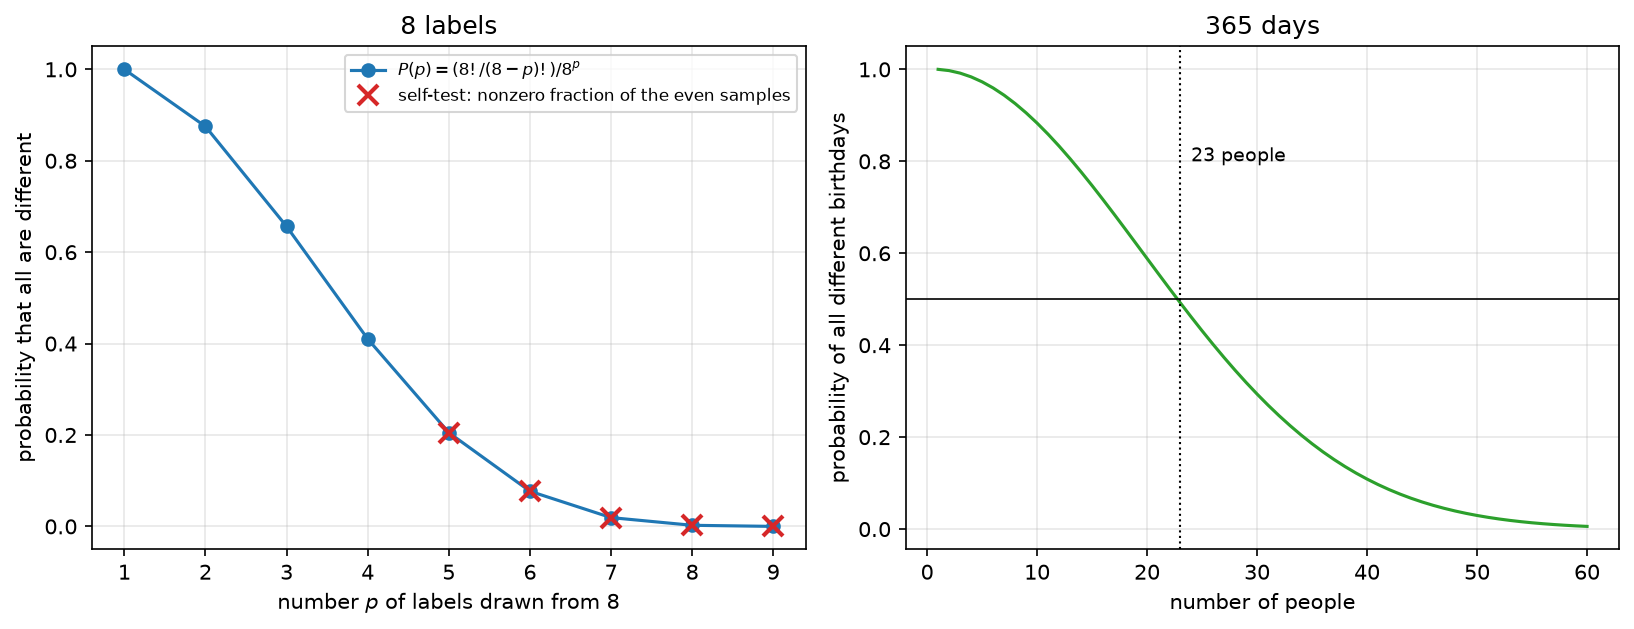

Figure 01d.6 saved as Revision/textbook/figures/01d_6_birthday_problem.png


In [13]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.3))
p_values = np.arange(1, 10)
left.plot(p_values, [all_different(int(p)) for p in p_values], "o-", color="tab:blue",
          label="$P(p) = (8!/(8-p)!)/8^p$")
left.plot([5, 6, 7, 8, 9], [selftest_rows[p]["even"] / 100000 for p in (5, 6, 7, 8, 9)],
          "x", color="tab:red", ms=10, mew=2,
          label="self-test: nonzero fraction of the even samples")
left.set_xlabel("number $p$ of labels drawn from 8")
left.set_ylabel("probability that all are different")
left.set_title("8 labels")
left.legend(fontsize=8)
people = np.arange(1, 61)
right.plot(people, [all_different(int(k), 365) for k in people], color="tab:green")
right.axhline(0.5, color="black", lw=0.8)
right.axvline(23, color="black", ls=":", lw=1)
right.text(24, 0.8, "23 people", fontsize=9)
right.set_xlabel("number of people")
right.set_ylabel("probability of all different birthdays")
right.set_title("365 days")
fig.tight_layout()
save_figure(fig, "birthday_problem",
            "Left: the probability $P(p)$ that $p$ labels drawn at random from 8 "
            "are all different (blue circles, joined), and the fraction of the "
            "100,000 even samples of the record's self-test that gave a nonzero "
            "generalized delta, as regenerated here (red crosses, $p = 5$ to 9); "
            "horizontal axis $p$, vertical axis the probability. The crosses lie "
            "on the curve, and $P(9) = 0$. Right: the classic birthday problem, "
            "the probability that $k$ people have $k$ different birthdays among "
            "365 days, against $k$; it falls below one half (black line) at "
            "$k = 23$ (dotted line).")

## 13. The last check

The last cell checks that the six figure files of this notebook exist in the
folder Revision/textbook/figures and prints the number of checks that passed.

In [14]:
figure_names = ["01d_1_binary_counting.png", "01d_2_generator_step.png",
                "01d_3_generator_bits.png", "01d_4_label_histogram.png",
                "01d_5_record_counts.png", "01d_6_birthday_problem.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in figure_names),
      "all 6 figure files of this notebook exist")
all_checks_passed()

PASS all 6 figure files of this notebook exist
ALL 19 CHECKS PASSED (notebook 01d)


## 14. What this notebook showed

- Whole numbers are strings of bits; a signed byte stores $-1$ as 255; shifts,
  exclusive or and the cut to 64 bits are simple arithmetic on the bits.
- The generator `xorshift64*` of the Revision programs, written in Python, makes
  outputs that look random but are fixed by the seed; the exporter's seed is made
  of the hexadecimal digits of $\pi$.
- From the seeds and the recorded source code, the notebook regenerates all
  3,161,984 bytes of GKD values that the Rust exporter gave the Wolfram check;
  their sha256 fingerprint is the one in the record, so every byte is the same.
  Every number of the record's `gkdComparison` table (346,304 pairs, the counts
  of $+1$, $-1$ and 0, no mismatch with the author's determinant, the negative
  control) is reproduced.
- The Rust self-test for the lengths 5 to 9 is reproduced exactly: 200,000 pairs
  each, the nonzero counts 20538, 7812, 1949, 244 and 0, and no mismatch with the
  determinant.
- These counts are what the birthday problem predicts: $p$ labels drawn from 8
  are all different with the probability $8!/((8-p)!\,8^p)$, which is 0 for
  $p = 9$.
- A pseudo-random test is evidence, not a proof; the proof that GKD equals the
  author's determinant is the four-case argument of notebook 01c. The record's
  numbers are exactly reproducible, which is what a record must be.